In [1]:
import pandas as pd

df = pd.read_csv("public.dat", delim_whitespace=True)
df.head()

/tmp/ipykernel_9660/1961389511.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("public.dat", delim_whitespace=True)


,46,1,0,0.1,0.2,0.3,0.4,1.1,0.5,0.6,...,0.08,1.6,2.1,6.50.1,16.50.1,1.03.2,..3,0.94,4,4.1
0,49,2,0,0,0,0,0,1,0,0,...,0.05,0,2,10.00,13.00,1.01,0.89,2.35,4,4
1,506,2,1,0,0,0,0,1,0,0,...,0.25,.,1,11.00,11.00,0.95,0.74,2.33,4,3
2,56,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,0.92,0.79,0.87,2,2
3,61,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,1.01,0.84,0.95,2,2
4,62,4,1,0,0,0,0,1,0,0,...,.,0,2,10.00,12.00,.,0.84,1.79,3,3


In [3]:
df.columns

Index(['46', '1', '0', '0.1', '0.2', '0.3', '0.4', '1.1', '0.5', '0.6', '0.7',
       '30.00', '15.00', '3.00', '.', '19.0', '..1', '1.2', '..2', '2', '6.50',
       '16.50', '1.03', '1.03.1', '0.52', '3', '3.1', '1.3', '1.4', '111792',
       '1.5', '3.50', '35.00', '3.00.1', '4.30', '26.0', '0.08', '1.6', '2.1',
       '6.50.1', '16.50.1', '1.03.2', '..3', '0.94', '4', '4.1'],
      dtype='object')

In [4]:
df = pd.read_csv("public.dat", delim_whitespace=True, header=None)

/tmp/ipykernel_9660/1319188131.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("public.dat", delim_whitespace=True, header=None)


In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
0,46,1,0,0,0,0,0,1,0,0,...,0.08,1,2,6.50,16.50,1.03,.,0.94,4,4
1,49,2,0,0,0,0,0,1,0,0,...,0.05,0,2,10.00,13.00,1.01,0.89,2.35,4,4
2,506,2,1,0,0,0,0,1,0,0,...,0.25,.,1,11.00,11.00,0.95,0.74,2.33,4,3
3,56,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,0.92,0.79,0.87,2,2
4,61,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,1.01,0.84,0.95,2,2


In [6]:
df.shape

(410, 46)

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("public.dat", sep=r"\s+", header=None)
df = df.replace(".", np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
0,46,1,0,0,0,0,0,1,0,0,...,0.08,1.0,2.0,6.5,16.5,1.03,NaN,0.94,4.0,4.0
1,49,2,0,0,0,0,0,1,0,0,...,0.05,0.0,2.0,10.0,13.0,1.01,0.89,2.35,4.0,4.0
2,506,2,1,0,0,0,0,1,0,0,...,0.25,NaN,1.0,11.0,11.0,0.95,0.74,2.33,4.0,3.0
3,56,4,1,0,0,0,0,1,0,0,...,0.15,0.0,2.0,10.0,12.0,0.92,0.79,0.87,2.0,2.0
4,61,4,1,0,0,0,0,1,0,0,...,0.15,0.0,2.0,10.0,12.0,1.01,0.84,0.95,2.0,2.0


In [9]:
df["emp_before"] = df[7] + 0.5 * df[8]
df["emp_after"] = df[27] + 0.5 * df[28]

In [10]:
df[[7, 8, 27, 28, "emp_before", "emp_after"]].head()

,7,8,27,28,emp_before,emp_after
0,1,0,1,1,1.0,1.5
1,1,0,1,1,1.0,1.5
2,1,0,1,1,1.0,1.5
3,1,0,1,1,1.0,1.5
4,1,0,1,1,1.0,1.5


In [11]:
df = pd.read_csv("public.dat", sep=r"\s+", header=None)

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("public.dat", sep=r"\s+", header=None)
df = df.replace(".", np.nan)
df = df.apply(pd.to_numeric, errors="coerce")

df["emp_before"] = df[7] + 0.5 * df[8]
df["emp_after"] = df[27] + 0.5 * df[28]
df["treated"] = df[1]
df["diff"] = df["emp_after"] - df["emp_before"]

print(df[[7, 8, 27, 28, "emp_before", "emp_after", "treated", "diff"]].head())

print(df.groupby("treated")["diff"].mean())

did = (
    df.loc[df["treated"] == 1, "diff"].mean()
    - df.loc[df["treated"] == 0, "diff"].mean()
)

print("DiD estimate:", did)

   7  8  27  28  emp_before  emp_after  treated  diff
0  1  0   1   1         1.0        1.5        1   0.5
1  1  0   1   1         1.0        1.5        2   0.5
2  1  0   1   1         1.0        1.5        2   0.5
3  1  0   1   1         1.0        1.5        4   0.5
4  1  0   1   1         1.0        1.5        4   0.5
treated
1    1.467836
2    1.400000
3    1.616162
4    1.391667
Name: diff, dtype: float64
DiD estimate: nan


In [14]:
# 正确 treated
df["treated"] = (df[1] == 1).astype(int)

# employment
df["emp_before"] = df[7] + 0.5 * df[8]
df["emp_after"] = df[27] + 0.5 * df[28]

# diff
df["diff"] = df["emp_after"] - df["emp_before"]

# 看分组均值
print(df.groupby("treated")["diff"].mean())

# DiD
did = (
    df.loc[df["treated"] == 1, "diff"].mean()
    - df.loc[df["treated"] == 0, "diff"].mean()
)

print("DiD estimate:", did)

treated
0    1.487448
1    1.467836
Name: diff, dtype: float64
DiD estimate: -0.01961144143482829


In [15]:
for col in range(46):
    print(col, df[col].dropna().head().tolist(), " | mean =", df[col].mean())

0 [46, 49, 506, 56, 61]  | mean = 246.50731707317073
1 [1, 2, 2, 4, 4]  | mean = 2.1170731707317074
2 [0, 0, 1, 1, 1]  | mean = 0.3439024390243902
3 [0, 0, 0, 0, 0]  | mean = 0.8073170731707318
4 [0, 0, 0, 0, 0]  | mean = 0.22682926829268293
5 [0, 0, 0, 0, 0]  | mean = 0.15365853658536585
6 [0, 0, 0, 0, 0]  | mean = 0.4268292682926829
7 [1, 1, 1, 1, 1]  | mean = 0.08780487804878048
8 [0, 0, 0, 0, 0]  | mean = 0.1048780487804878
9 [0, 0, 0, 0, 0]  | mean = 0.08536585365853659
10 [0, 0, 0, 0, 0]  | mean = 1.1414634146341462
11 [30.0, 6.5, 3.0, 20.0, 6.0]  | mean = 8.202970297029703
12 [15.0, 6.5, 7.0, 20.0, 26.0]  | mean = 18.83128078817734
13 [3.0, 4.0, 2.0, 4.0, 5.0]  | mean = 3.42029702970297
14 [5.0, 5.5, 5.0, 5.0, 5.0]  | mean = 4.615641025641025
15 [19.0, 26.0, 13.0, 26.0, 52.0]  | mean = 18.310026385224276
16 [0.37, 0.1, 0.15, 0.07, 0.1]  | mean = 0.22528610354223436
17 [1, 0, 0, 1, 1]  | mean = 0.24634146341463414
18 [30.0, 0.0, 0.0, 45.0, 0.0]  | mean = 48.86967213114754
19 [2, 

Summary by treated status:
         emp_before  emp_after      diff
treated                                 
0         20.354803  16.983543 -3.084515
1         21.871598  20.340767 -1.848082

DiD estimate: 1.236433114341627

Four-cell means:
NJ before: 21.871597633136094
NJ after : 20.340766666666664
PA before: 20.354803493449783
PA after : 16.98354271356784


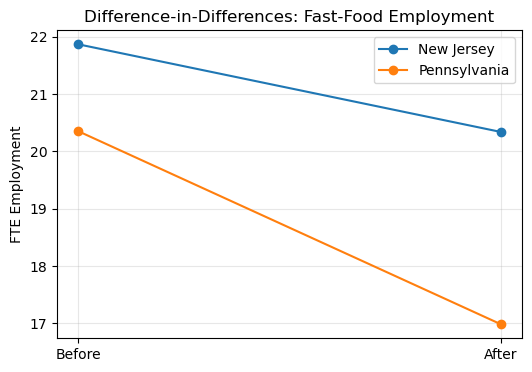

In [20]:
import pandas as pd
import numpy as np

# 1. 读取数据
df = pd.read_csv("public.dat", sep=r"\s+", header=None)

# 2. 把 "." 变成缺失值，再全部转成数值
df = df.replace(".", np.nan)
df = df.apply(pd.to_numeric, errors="coerce")

# 3. 构造 treatment 变量
# 这里按你前面跑出来的结果，1 表示 New Jersey，其他表示 Pennsylvania/其他编码
df["treated"] = (df[6] == 1).astype(int)

# 4. 构造论文中的 FTE employment
# FTE = full-time + managers + 0.5 * part-time

# before (wave 1)
df["emp_before"] = df[11] + df[13] + 0.5 * df[12]

# after (wave 2)
df["emp_after"] = df[15] + df[17] + 0.5 * df[16]

# 5. 构造变化量
df["diff"] = df["emp_after"] - df["emp_before"]

# 6. 看看 NJ 和 PA 的 before / after 平均值
summary = df.groupby("treated")[["emp_before", "emp_after", "diff"]].mean()
print("Summary by treated status:")
print(summary)

# 7. 计算最简单的 Difference-in-Differences
did = (
    df.loc[df["treated"] == 1, "diff"].mean()
    - df.loc[df["treated"] == 0, "diff"].mean()
)

print("\nDiD estimate:", did)

# 8. 再把 four-cell mean 打出来，方便你写作业
nj_before = df.loc[df["treated"] == 1, "emp_before"].mean()
nj_after  = df.loc[df["treated"] == 1, "emp_after"].mean()
pa_before = df.loc[df["treated"] == 0, "emp_before"].mean()
pa_after  = df.loc[df["treated"] == 0, "emp_after"].mean()

print("\nFour-cell means:")
print("NJ before:", nj_before)
print("NJ after :", nj_after)
print("PA before:", pa_before)
print("PA after :", pa_after)

# 9. 可选：画一个最简单的 DiD 图
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(["Before", "After"], [nj_before, nj_after], marker="o", label="New Jersey")
plt.plot(["Before", "After"], [pa_before, pa_after], marker="o", label="Pennsylvania")
plt.ylabel("FTE Employment")
plt.title("Difference-in-Differences: Fast-Food Employment")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()